In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.formula.api as smf
import statsmodels.api as sm

In [26]:
# Load data
df = pd.read_csv('Data/Clean/Final-v4.csv')

In [27]:
EU27 = [
    "AUT","BEL","BGR","HRV","CYP","CZE","DNK","EST","FIN","FRA","DEU","GRC",
    "HUN","IRL","ITA","LVA","LTU","LUX","MLT","NLD","POL","PRT","ROU","SVK",
    "SVN","ESP","SWE",
]
OUTSIDE   = ["USA","GBR","CHE","NOR"]
COUNTRIES = EU27 + OUTSIDE          # n = 31

# df = df[df["iso3_i"].isin(COUNTRIES) & df["iso3_j"].isin(COUNTRIES)].copy()

In [28]:
df.columns

Index(['iso3_i', 'iso3_j', 'year', 'a_ij', 'M_i', 'M_j', 'd_cul', 'r_i', 'r_j',
       'Y_i', 'k_i', 'L_i', 'pop_i', 'lab_sh_i', 'delta_i', 'A_i', 'rf_i',
       'inv_share_i', 'hc_i', 'alpha_i', 'Y_j', 'k_j', 'L_j', 'pop_j',
       'lab_sh_j', 'delta_j', 'A_j', 'rf_j', 'inv_share_j', 'hc_j', 'alpha_j',
       'bis_debt_i', 'gci_corruption_i', 'gci_financial_composite_i',
       'gci_overall_i', 'gci_trade_openness_i', 'gci_corruption_j',
       'gci_financial_composite_j', 'gci_overall_j', 'gci_trade_openness_j',
       'a_ij_lag1', 'R_i', 'R_j', 'd_geo', 'border', 'legal_origin',
       'language_proximity', 'lang_share', 'lang_official', 'legal_origin_i',
       'legal_origin_j', 'fta_wto', 'euro_i', 'euro_j', 'd_ling', 'eu_i',
       'eu_j'],
      dtype='str')

In [29]:
# df["d_ling"] = 1 - df["lang_share"]
# df["ln_d_geo"] = np.log(df["d_geo"])
# df["ln_a_ij"] = np.log1p(df["a_ij"])
# df["euro_ij"] = df["euro_i"] * df["euro_j"]

# # Replace inf with nan in ln_d_geo
# df = df.replace([np.inf, -np.inf], np.nan)

In [30]:
# # Standardise each component to [0, 1] range
# geo_norm = (df['ln_d_geo'] - df['ln_d_geo'].min()) / (df['ln_d_geo'].max() - df['ln_d_geo'].min())
# ling_norm = df['d_ling']  # already 0-1
# cul_norm = df['d_cul'] / df['d_cul'].max()  # scale to 0-1

# # Composite: average of available components
# df['d_composite'] = pd.concat([geo_norm, ling_norm, cul_norm], axis=1).mean(axis=1, skipna=True)

In [33]:
ppml_df = df[df["iso3_i"] != df["iso3_j"]].copy()

ppml_df = ppml_df[ppml_df["iso3_i"].isin(COUNTRIES) & ppml_df["iso3_j"].isin(COUNTRIES)].copy()

# Construct distance in gci columns
ppml_df["d_gci_overall"] = np.abs(ppml_df["gci_overall_i"] - ppml_df["gci_overall_j"])
ppml_df["d_gci_corruption"] = np.abs(ppml_df["gci_corruption_i"] - ppml_df["gci_corruption_j"])
ppml_df["d_gci_trade_openness"] = np.abs(ppml_df["gci_trade_openness_i"] - ppml_df["gci_trade_openness_j"])
ppml_df["d_gci_financial_composite"] = np.abs(ppml_df["gci_financial_composite_i"] - ppml_df["gci_financial_composite_j"])

cols = ["a_ij", "d_ling", "d_gci_financial_composite", "year", "iso3_i", "iso3_j", "Y_i", "Y_j"]
# ppml_df = ppml_df.dropna(subset=cols).copy()
ppml_df = ppml_df[ppml_df["a_ij"] > 0].copy()

# Create bilateral pair identifier for clustering
ppml_df['pair'] = ppml_df['iso3_i'] + '_' + ppml_df['iso3_j']

# ppml_df = ppml_df.fillna(0)
ppml_df = ppml_df.dropna(subset=cols).copy()

# Change Y to /1e3 and round to reduce massive numbers in interaction term
ppml_df["Y_i"] = ppml_df["Y_i"].div(1e6).round(3)
ppml_df["Y_j"] = ppml_df["Y_j"].div(1e6).round(3)
ppml_df["a_ij"] = ppml_df["a_ij"].div(1e6).round(3)


num_cols = ppml_df[cols].select_dtypes(include=[np.number]).columns

formula = 'a_ij ~ d_ling + d_gci_financial_composite + Y_i*Y_j + C(year)'
model = smf.poisson(
    formula=formula,
    data=ppml_df,
).fit(
    method="newton",      # Use Newton-Raphson instead of BFGS
    maxiter=300,
    cov_type="cluster",
    cov_kwds={"groups": ppml_df['pair']},
)

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.018749
         Iterations 20
                          Poisson Regression Results                          
Dep. Variable:                   a_ij   No. Observations:                 2400
Model:                        Poisson   Df Residuals:                     2392
Method:                           MLE   Df Model:                            7
Date:                Thu, 09 Apr 2026   Pseudo R-squ.:                  0.1724
Time:                        17:03:49   Log-Likelihood:                -44.999
converged:                       True   LL-Null:                       -54.373
Covariance Type:              cluster   LLR p-value:                  0.009012
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    -3.6012      0.258    -13.960      0.000      -4

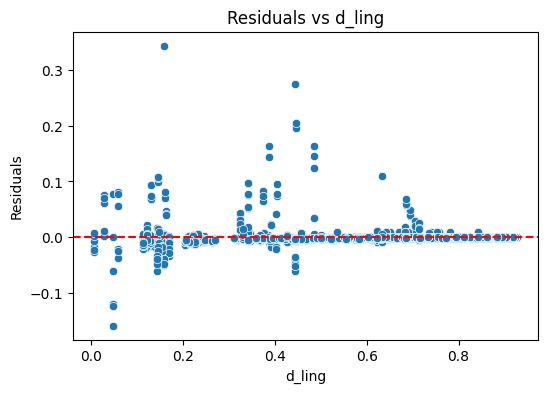

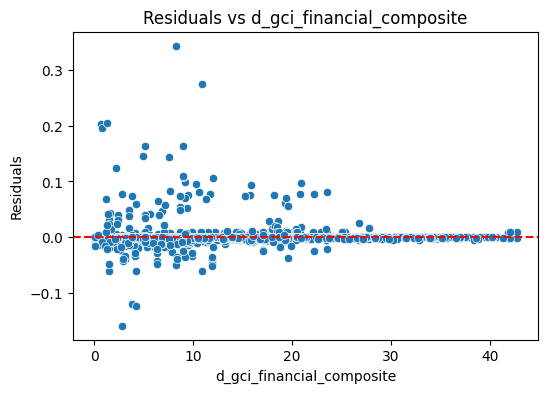

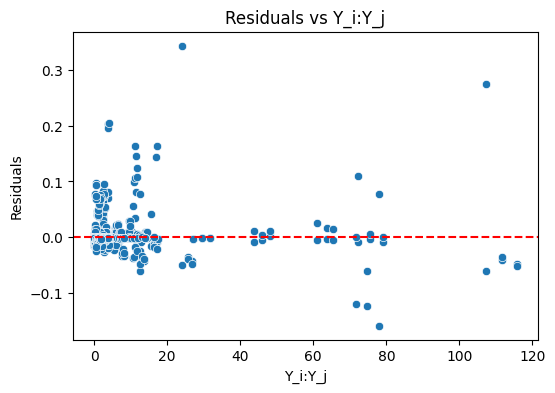

In [32]:
# plot scatter plots of residual against all of the variables in the model
residuals = model.resid_response
ppml_df["Y_i:Y_j"] = ppml_df["Y_i"] * ppml_df["Y_j"]

for col in ["d_ling", "d_gci_financial_composite", "Y_i:Y_j"]:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=ppml_df[col], y=residuals)
    plt.title(f"Residuals vs {col}")
    plt.xlabel(col)
    plt.ylabel("Residuals")
    plt.axhline(0, color='red', linestyle='--')
    plt.show()

In [29]:
# # Clip the data to remove outliers. Remove bottom Xpct and top 1-Xpct
# pct = 0.02
# df = df[df["ln_a_ij"].between(df["ln_a_ij"].quantile(pct), df["ln_a_ij"].quantile(1 - pct))].copy()

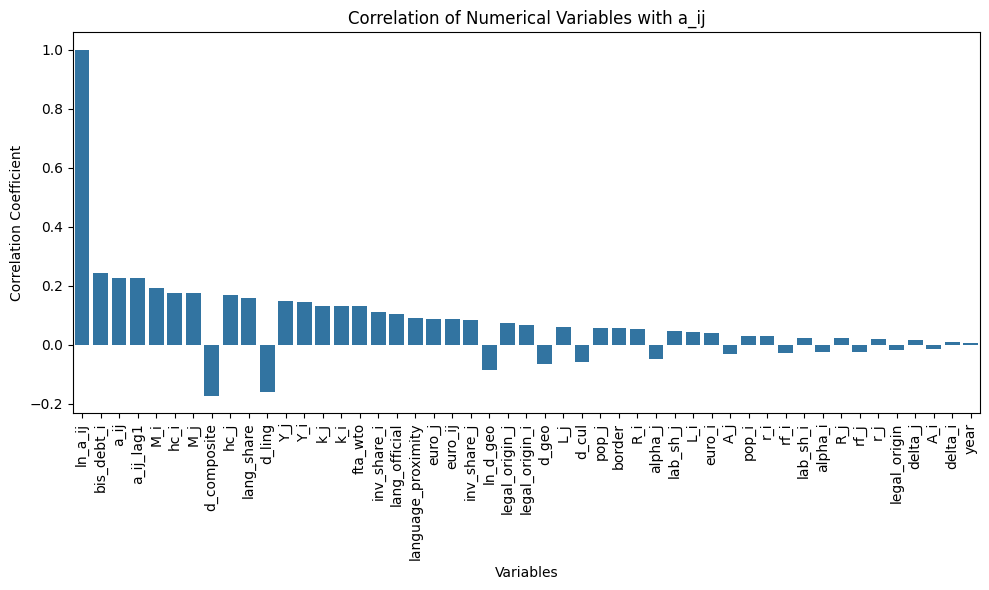

In [77]:
# Get simple correlation vector against a_ij
num_cols = df.select_dtypes(include=[np.number]).columns
correlations = df[num_cols].corr()['ln_a_ij'].sort_values(ascending=False, key=abs)

# Plot correlations as bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x=correlations.index, y=correlations.values)
plt.xticks(rotation=90)
plt.title('Correlation of Numerical Variables with a_ij')
plt.ylabel('Correlation Coefficient')
plt.xlabel('Variables')
plt.tight_layout()
plt.show()

We clearly see that culture has a huge impact on bilateral trade. It is the largest impact out of the friction barriers we have included so far (culture, border, distance, language). However, when we have run the gravity model, we have seen that these friction variables get positive coefficients. Which is not right. Therefore, we need to inspect what it is that is causing this. Because the variables are likely absorbing other factors or suffers from collinearity.

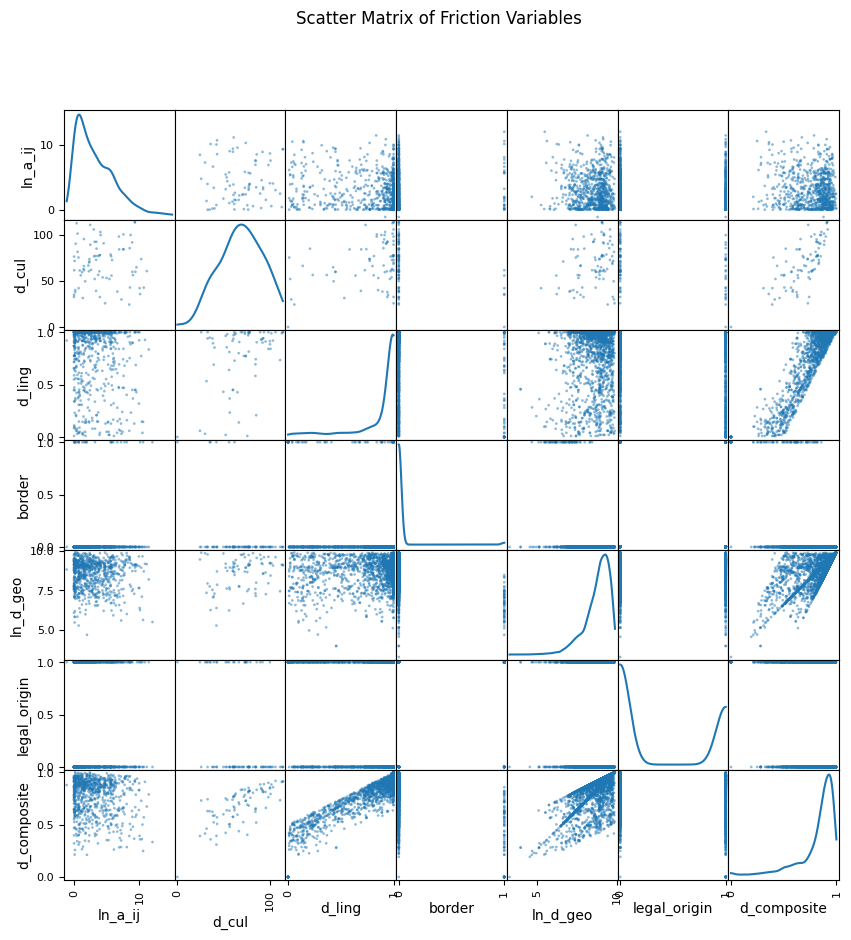

In [78]:
# Plot a scatter matrix between the friction 
# variables to find out how they interact with 
# each other
from pandas.plotting import scatter_matrix
fric_cols = ["ln_a_ij", "d_cul", "d_ling", "border", "ln_d_geo", "legal_origin", "d_composite"]
tf = df[fric_cols].copy().sample(5_000)

scatter_matrix(tf, figsize=(10, 10), diagonal='kde', s=15, alpha=0.5)
plt.suptitle('Scatter Matrix of Friction Variables')
plt.show()

In [79]:
tf.corr()

,ln_a_ij,d_cul,d_ling,border,ln_d_geo,legal_origin,d_composite
ln_a_ij,1.000000,0.014064,-0.105411,0.062114,-0.049353,-0.006144,-0.129874
d_cul,0.014064,1.000000,0.390847,-0.352150,0.260014,-0.336563,0.725826
d_ling,-0.105411,0.390847,1.000000,-0.253059,0.189587,-0.143444,0.908712
border,0.062114,-0.352150,-0.253059,1.000000,-0.316120,0.093177,-0.394040
ln_d_geo,-0.049353,0.260014,0.189587,-0.316120,1.000000,-0.087032,0.701023
legal_origin,-0.006144,-0.336563,-0.143444,0.093177,-0.087032,1.000000,-0.141882
d_composite,-0.129874,0.725826,0.908712,-0.394040,0.701023,-0.141882,1.000000


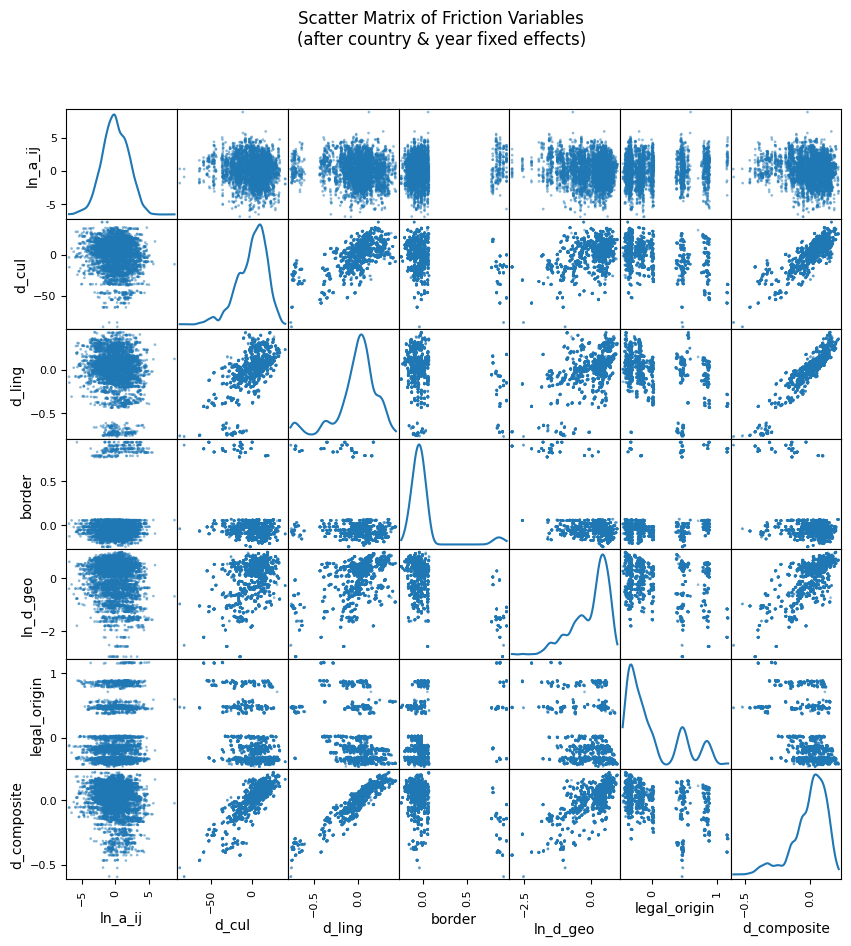

In [80]:
# Scatter matrix of friction variables after partialling out country & year fixed effects
# (Frisch-Waugh: regress each variable on FE dummies, take residuals)
fe_formula_base = 'C(year) + C(iso3_i) + C(iso3_j) + 0'

fe_residuals = {}
sample = df[df["iso3_i"] != df["iso3_j"]].dropna(subset=fric_cols + ["year", "iso3_i", "iso3_j"])

for col in fric_cols:
    fe_mod = smf.ols(f'{col} ~ {fe_formula_base}', data=sample).fit()
    fe_residuals[col] = fe_mod.resid

fe_resid_df = pd.DataFrame(fe_residuals, index=sample.index)
n_sample = min(5_000, len(fe_resid_df))
fe_resid_df = fe_resid_df.sample(n_sample, random_state=42)

scatter_matrix(fe_resid_df, figsize=(10, 10), diagonal='kde', s=15, alpha=0.5)
plt.suptitle('Scatter Matrix of Friction Variables\n(after country & year fixed effects)')
plt.show()


In [81]:
fe_resid_df.corr()

,ln_a_ij,d_cul,d_ling,border,ln_d_geo,legal_origin,d_composite
ln_a_ij,1.000000,-0.101514,-0.117047,0.120726,-0.160227,0.112252,-0.145317
d_cul,-0.101514,1.000000,0.634416,-0.274906,0.403555,-0.391286,0.814822
d_ling,-0.117047,0.634416,1.000000,-0.267048,0.503835,-0.372104,0.927427
border,0.120726,-0.274906,-0.267048,1.000000,-0.505806,0.268077,-0.384355
ln_d_geo,-0.160227,0.403555,0.503835,-0.505806,1.000000,-0.299462,0.698320
legal_origin,0.112252,-0.391286,-0.372104,0.268077,-0.299462,1.000000,-0.428393
d_composite,-0.145317,0.814822,0.927427,-0.384355,0.698320,-0.428393,1.000000


In [82]:
# Make plot data, which does not include i=j
plot_df = df[df["iso3_i"] != df["iso3_j"]].copy()

In [83]:
# Fit an OLS on a_ij with constants for year, iso3_i, iso3_j
# and then only include d_cul as the only exogenous variable.
# Plus an intercept term.

formula = 'a_ij ~ d_cul + C(year) + C(iso3_i) + C(iso3_j) + 0'
model = smf.ols(formula=formula, data=plot_df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   a_ij   R-squared:                       0.235
Model:                            OLS   Adj. R-squared:                  0.227
Method:                 Least Squares   F-statistic:                     30.87
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:19:26   Log-Likelihood:                -80836.
No. Observations:                7101   AIC:                         1.618e+05
Df Residuals:                    7030   BIC:                         1.623e+05
Df Model:                          70                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
C(year)[2017]       9342.4826    988

In [84]:
# Extend the previous one to include language as well
formula = 'a_ij ~ d_cul + d_ling + C(year) + C(iso3_i) + C(iso3_j) + 0'
model = smf.ols(formula=formula, data=plot_df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   a_ij   R-squared:                       0.224
Model:                            OLS   Adj. R-squared:                  0.216
Method:                 Least Squares   F-statistic:                     26.15
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:19:32   Log-Likelihood:                -69012.
No. Observations:                6129   AIC:                         1.382e+05
Df Residuals:                    6061   BIC:                         1.386e+05
Df Model:                          67                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
C(year)[2017]       8391.6874    941

In [85]:
# Extend the previous one to include d-geo as well
formula = 'a_ij ~ a_ij_lag1 + d_cul + d_ling + d_geo + C(year) + C(iso3_i) + C(iso3_j) + 0'
model = smf.ols(formula=formula, data=plot_df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   a_ij   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                 2.627e+04
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:19:37   Log-Likelihood:                -49711.
No. Observations:                5826   AIC:                         9.956e+04
Df Residuals:                    5756   BIC:                         1.000e+05
Df Model:                          69                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
C(year)[2017]       -131.6451     71

In [86]:
formula = 'a_ij ~ d_cul + d_ling + border + C(year) + C(iso3_i) + C(iso3_j) + 0'
model = smf.ols(formula=formula, data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   a_ij   R-squared:                       0.232
Model:                            OLS   Adj. R-squared:                  0.223
Method:                 Least Squares   F-statistic:                     26.94
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:19:43   Log-Likelihood:                -68981.
No. Observations:                6129   AIC:                         1.381e+05
Df Residuals:                    6060   BIC:                         1.386e+05
Df Model:                          68                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
C(year)[2017]       6426.9887    969

In [87]:
formula = 'ln_a_ij ~ d_ling + border + legal_origin + C(year) + C(iso3_i) + C(iso3_j) + 0'
model = smf.ols(formula=formula, data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                ln_a_ij   R-squared:                       0.489
Model:                            OLS   Adj. R-squared:                  0.485
Method:                 Least Squares   F-statistic:                     157.7
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:19:57   Log-Likelihood:            -1.2985e+05
No. Observations:               64803   AIC:                         2.605e+05
Df Residuals:                   64412   BIC:                         2.640e+05
Df Model:                         390                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
C(year)[2017]         -0.8399      0

In [88]:
df["ln_Y_i"] = df["Y_i"].apply(np.log)
df["ln_Y_j"] = df["Y_j"].apply(np.log)

df["ln_M_i"] = df["M_i"].apply(np.log)
df["ln_M_j"] = df["M_j"].apply(np.log)


formula = 'ln_a_ij ~ d_ling + ln_d_geo + legal_origin + ln_M_i*ln_M_j + C(year)'
model = smf.ols(formula=formula, data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                ln_a_ij   R-squared:                       0.224
Model:                            OLS   Adj. R-squared:                  0.224
Method:                 Least Squares   F-statistic:                     1280.
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:19:59   Log-Likelihood:            -1.1784e+05
No. Observations:               53185   AIC:                         2.357e+05
Df Residuals:                   53172   BIC:                         2.358e+05
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          10.3937      0.794     

In [89]:
# Create d_composite if it doesn't exist
if 'd_composite' not in df.columns:
    geo_norm = (df['d_geo'] - df['d_geo'].min()) / (df['d_geo'].max() - df['d_geo'].min())
    ling_norm = 1 - df['lang_share']  # d_ling
    cul_norm = df['d_cul'] / df['d_cul'].max()
    df['d_composite'] = pd.concat([geo_norm, ling_norm, cul_norm], axis=1).mean(axis=1, skipna=True)

# PPML gravity model - use raw a_ij (not log), drop i=j, drop NaNs
ppml_df = df[df["iso3_i"] != df["iso3_j"]].copy()
cols = ["a_ij", "d_geo", "d_ling", "border", "legal_origin", "year", "iso3_i", "iso3_j", "ln_Y_i", "ln_Y_j"]
ppml_df = ppml_df.dropna(subset=cols).copy()

# Ensure a_ij > 0 for Poisson model
ppml_df = ppml_df[ppml_df["a_ij"] > 0].copy()

# add log(Y_i * Y_j)
formula = 'a_ij ~ d_geo + d_ling + border + legal_origin_i + legal_origin_j + ln_Y_i*ln_Y_j + C(year)'
model = smf.poisson(
    formula=formula,
    data=ppml_df,
).fit(
    method="bfgs",
    maxiter=500,
    cov_type="cluster",
    cov_kwds={"groups": ppml_df[["year"]].astype(str).agg('_'.join, axis=1)},
)
print(model.summary())

/Users/jesper/Desktop/CBS/Thesis 1/Jesper-Liedholm-Thesis-Code/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/Users/jesper/Desktop/CBS/Thesis 1/Jesper-Liedholm-Thesis-Code/.venv/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:1478: RuntimeWarning: overflow encountered in exp
  L = np.exp(np.dot(X,params) + offset + exposure)
/Users/jesper/Desktop/CBS/Thesis 1/Jesper-Liedholm-Thesis-Code/.venv/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:1479: RuntimeWarning: invalid value encountered in dot
  return np.dot(self.endog - L, X)
/Users/jesper/Desktop/CBS/Thesis 1/Jesper-Liedholm-Thesis-Code/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/Users/jesper/Desktop/CBS/Thesis 1/Jesper-Liedholm-Thesis-Code/.v

         Current function value: 2743769.553702
         Iterations: 1
         Function evaluations: 15
         Gradient evaluations: 4


ValueError: The weights and list don't have the same length.

In [98]:
ppml_df[cols].describe()

,a_ij,d_geo,d_ling,border,legal_origin_i,legal_origin_j,year,ln_Y_i,ln_Y_j
count,8.953500e+04,89535.000000,89535.000000,89535.000000,89535.000000,89535.000000,89535.000000,89535.000000,89535.000000
mean,6.670928e+03,6288.327746,0.580493,0.024046,1.582990,1.561077,2020.485453,9.953237,9.871952
std,1.077907e+05,4634.849910,0.429550,0.153194,1.088153,1.078444,2.281041,5.530967,5.558601
min,1.000000e-16,0.000000,0.000000,0.000000,0.000000,0.000000,2017.000000,0.000000,0.000000
25%,1.132600e+00,2081.107961,0.000000,0.000000,1.000000,1.000000,2019.000000,8.379728,8.344089
50%,1.074720e+01,6013.048095,0.774600,0.000000,1.000000,1.000000,2020.000000,12.169340,12.089528
75%,1.110239e+02,9368.098074,0.990400,0.000000,2.000000,2.000000,2022.000000,13.722120,13.610738
max,6.606100e+06,19854.348174,1.000000,1.000000,5.000000,5.000000,2024.000000,17.251032,17.251032


## Analyse residuals.

We will run the OLS with the culture, language, and distance variables and then we will further analyse the residuals from this model. To see if there is any underlying that the 

In [23]:
# Now get the residuals and get correlation with d_cul, d_ling, d_geo
residuals = model.resid
residuals_df = pd.DataFrame({
    'residuals': residuals,
    'd_cul': plot_df['d_cul'],
    'd_ling': plot_df['d_ling'],
    'd_geo': plot_df['d_geo'],
    'd_cul_sq': plot_df['d_cul'] ** 2,
    'd_ling_sq': plot_df['d_ling'] ** 2,
    'd_geo_sq': plot_df['d_geo'] ** 2,
})
corr_residuals = residuals_df.corr()['residuals'].sort_values(ascending=False, key=abs)
print(corr_residuals.round(2))

residuals    1.00
d_geo       -0.12
d_geo_sq    -0.11
d_cul        0.09
d_cul_sq     0.07
d_ling_sq   -0.02
d_ling      -0.00
Name: residuals, dtype: float64
